## Importing Libraries 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [4]:
df = pd.read_csv(r'Real_Estate_Sales_2001-2022_GL-Short.csv')
df

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Non Use Code,Assessor Remarks,OPM remarks,Location
0,2020177,2020,04/14/2021,Ansonia,323 BEAVER ST,133000.0,248400.0,0.535400,Residential,Single Family,NaN,NaN,NaN,POINT (-73.06822 41.35014)
1,2020225,2020,05/26/2021,Ansonia,152 JACKSON ST,110500.0,239900.0,0.460600,Residential,Three Family,NaN,NaN,NaN,NaN
2,2020348,2020,09/13/2021,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.463000,Commercial,NaN,NaN,NaN,NaN,NaN
3,2020090,2020,12/14/2020,Ansonia,57 PLATT ST,127400.0,202500.0,0.629100,Residential,Two Family,NaN,NaN,NaN,NaN
4,200500,2020,09/07/2021,Avon,245 NEW ROAD,217640.0,400000.0,0.544100,Residential,Single Family,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,201166,2020,08/26/2021,Meriden,6006 MEETINGHOUSE VLG,59430.0,135000.0,0.440200,Residential,Condo,NaN,NaN,NaN,NaN
138,200177,2020,06/09/2021,Middlebury,289 BURR HALL RD,1144200.0,1676250.0,0.682595,Residential,Single Family,NaN,NaN,NaN,NaN
139,200531,2020,04/05/2021,Middletown,87 WESTWOOD LA,285040.0,400000.0,0.712600,Residential,Single Family,NaN,NaN,NaN,NaN
140,200888,2020,07/29/2021,Middletown,PHEDON PKWY,49220.0,100000.0,0.492200,Vacant Land,NaN,NaN,NaN,NaN,NaN


## EDA

In [5]:
df.head

<bound method NDFrame.head of      Serial Number  List Year Date Recorded        Town  \
0          2020177       2020    04/14/2021     Ansonia   
1          2020225       2020    05/26/2021     Ansonia   
2          2020348       2020    09/13/2021     Ansonia   
3          2020090       2020    12/14/2020     Ansonia   
4           200500       2020    09/07/2021        Avon   
..             ...        ...           ...         ...   
137         201166       2020    08/26/2021     Meriden   
138         200177       2020    06/09/2021  Middlebury   
139         200531       2020    04/05/2021  Middletown   
140         200888       2020    07/29/2021  Middletown   
141         200092       2020    11/02/2020  Middletown   

                   Address  Assessed Value  Sale Amount  Sales Ratio  \
0            323 BEAVER ST        133000.0     248400.0     0.535400   
1           152 JACKSON ST        110500.0     239900.0     0.460600   
2          230 WAKELEE AVE        150500.0   

In [6]:
df.shape

(142, 14)

In [7]:
df.info

<bound method DataFrame.info of      Serial Number  List Year Date Recorded        Town  \
0          2020177       2020    04/14/2021     Ansonia   
1          2020225       2020    05/26/2021     Ansonia   
2          2020348       2020    09/13/2021     Ansonia   
3          2020090       2020    12/14/2020     Ansonia   
4           200500       2020    09/07/2021        Avon   
..             ...        ...           ...         ...   
137         201166       2020    08/26/2021     Meriden   
138         200177       2020    06/09/2021  Middlebury   
139         200531       2020    04/05/2021  Middletown   
140         200888       2020    07/29/2021  Middletown   
141         200092       2020    11/02/2020  Middletown   

                   Address  Assessed Value  Sale Amount  Sales Ratio  \
0            323 BEAVER ST        133000.0     248400.0     0.535400   
1           152 JACKSON ST        110500.0     239900.0     0.460600   
2          230 WAKELEE AVE        150500.0 

In [8]:
df.describe()

,Serial Number,List Year,Assessed Value,Sale Amount,Sales Ratio,OPM remarks
count,1.420000e+02,142.0,1.420000e+02,1.420000e+02,142.000000,0.0
mean,6.650655e+05,2020.0,2.327889e+05,3.853573e+05,0.589640,NaN
std,2.875689e+06,0.0,3.529366e+05,5.086467e+05,0.160655,NaN
min,2.000100e+04,2020.0,6.230000e+03,1.000000e+04,0.119700,NaN
25%,2.000562e+05,2020.0,9.163250e+04,1.675000e+05,0.495175,NaN
50%,2.002020e+05,2020.0,1.457750e+05,2.600000e+05,0.552550,NaN
75%,2.007042e+05,2020.0,2.066500e+05,3.726250e+05,0.675575,NaN
max,2.000028e+07,2020.0,2.623950e+06,3.900000e+06,1.283000,NaN


In [9]:
df.isnull().sum()

Serial Number         0
List Year             0
Date Recorded         0
Town                  0
Address               0
Assessed Value        0
Sale Amount           0
Sales Ratio           0
Property Type         0
Residential Type     27
Non Use Code        134
Assessor Remarks    128
OPM remarks         142
Location            133
dtype: int64

## Data Cleaning 

In [10]:
# Drop rows where critical columns are missing
df_clean = df.dropna(subset=['Sale Amount', 'Town'])
print("After cleaning records:", len(df_clean))

After cleaning records: 142


## Top Towns By Listings

In [18]:
town_listings = df_clean['Town'].value_counts()
town_listings.head(10)

Town
Bristol          9
East Hartford    7
Branford         6
Groton           6
Meriden          6
Greenwich        6
Danbury          6
East Haven       5
Enfield          5
Ansonia          4
Name: count, dtype: int64

## Average Sale Amount by Town (Top 10)

In [11]:
avg_price_by_town = df_clean.groupby('Town')['Sale Amount'].mean().sort_values(ascending=False)
avg_price_by_town.head(10)

Town
Greenwich       2.209000e+06
Middlebury      1.676250e+06
Madison         1.050333e+06
Derby           8.730000e+05
Farmington      7.650000e+05
Darien          6.581663e+05
Killingworth    6.450000e+05
Goshen          6.280000e+05
Avon            5.875000e+05
Essex           5.416667e+05
Name: Sale Amount, dtype: float64

## Price Distribution (Histogram)

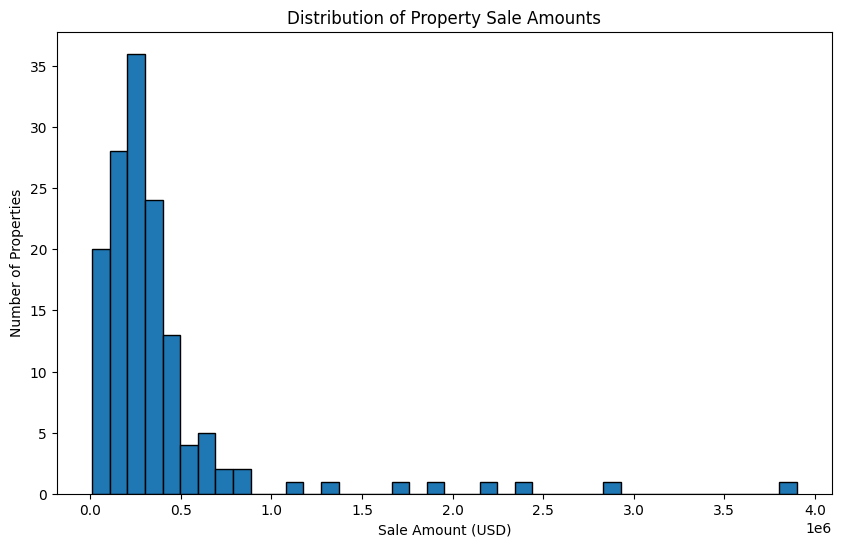

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Sale Amount'].dropna(), bins=40, edgecolor='black')
plt.xlabel('Sale Amount (USD)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Property Sale Amounts')
plt.show()

## Top 10 Most Expensive Towns

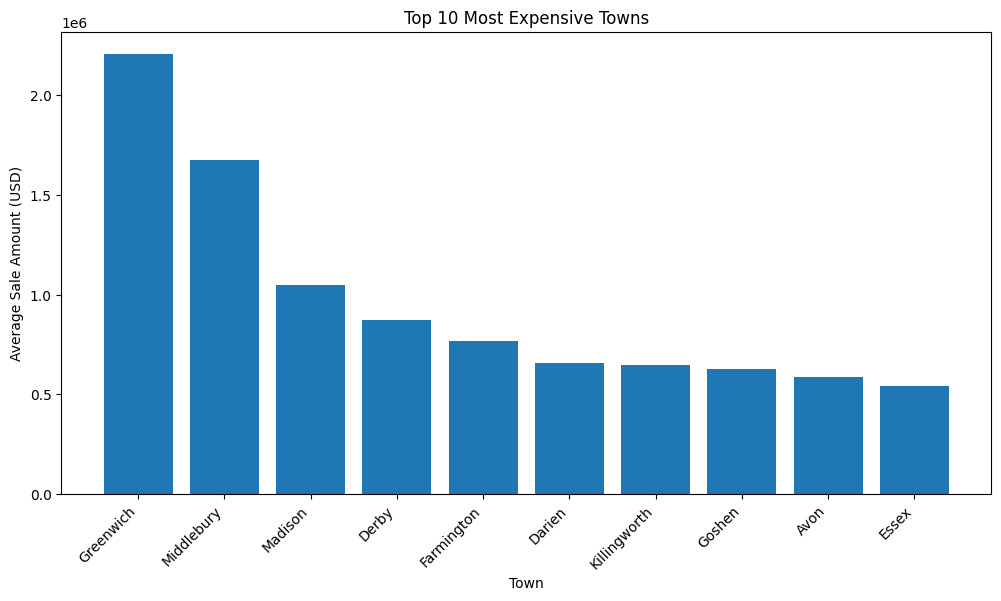

In [13]:
top_10_towns = avg_price_by_town.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_towns.index, top_10_towns.values)
plt.xlabel('Town')
plt.ylabel('Average Sale Amount (USD)')
plt.title('Top 10 Most Expensive Towns')
plt.xticks(rotation=45, ha='right')
plt.show()

## Sale Amount Distribution by Property Type

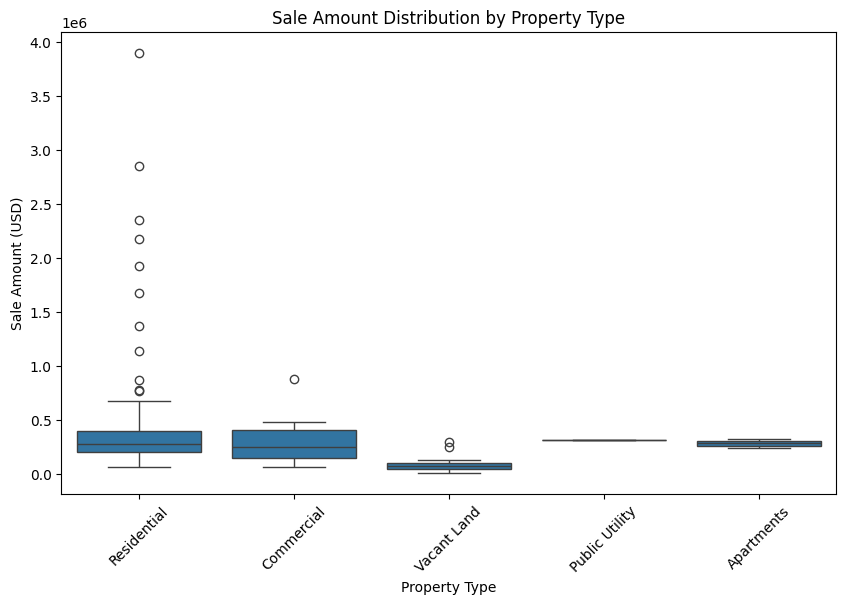

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Property Type', y='Sale Amount', data=df_clean)
plt.xlabel('Property Type')
plt.ylabel('Sale Amount (USD)')
plt.title('Sale Amount Distribution by Property Type')
plt.xticks(rotation=45)
plt.show()

## Assessed Value vs Sale Amount Relationship

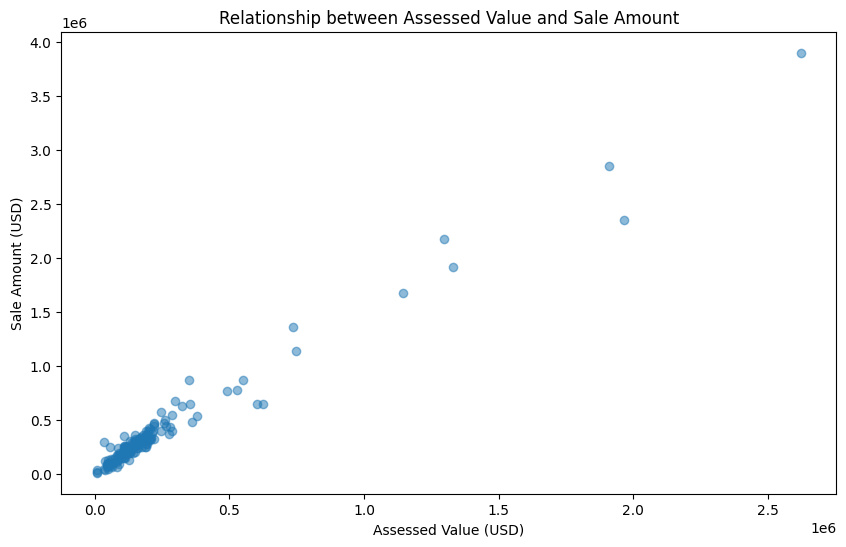

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Assessed Value'], df_clean['Sale Amount'], alpha=0.5)
plt.xlabel('Assessed Value (USD)')
plt.ylabel('Sale Amount (USD)')
plt.title('Relationship between Assessed Value and Sale Amount')
plt.show()

## Additional Sales Ratio Distribution

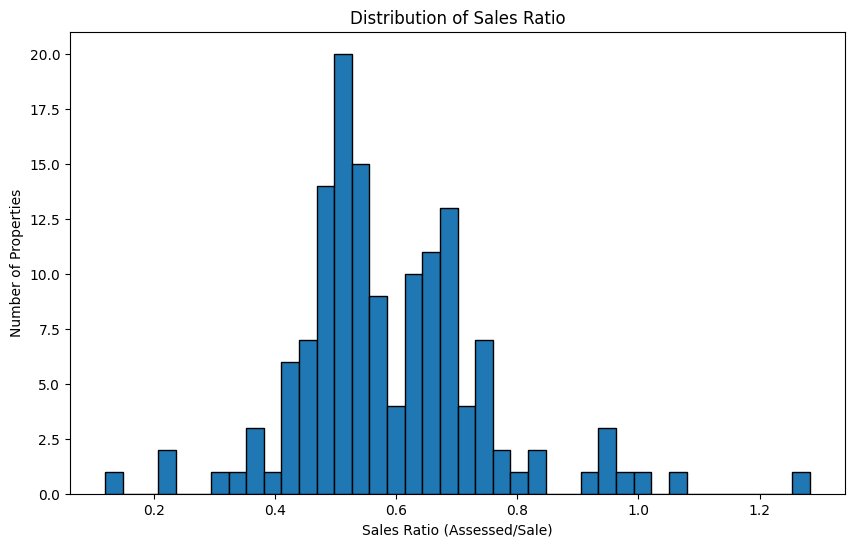

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Sales Ratio'].dropna(), bins=40, edgecolor='black')
plt.xlabel('Sales Ratio (Assessed/Sale)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Sales Ratio')
plt.show()

## Additional Sales by Year

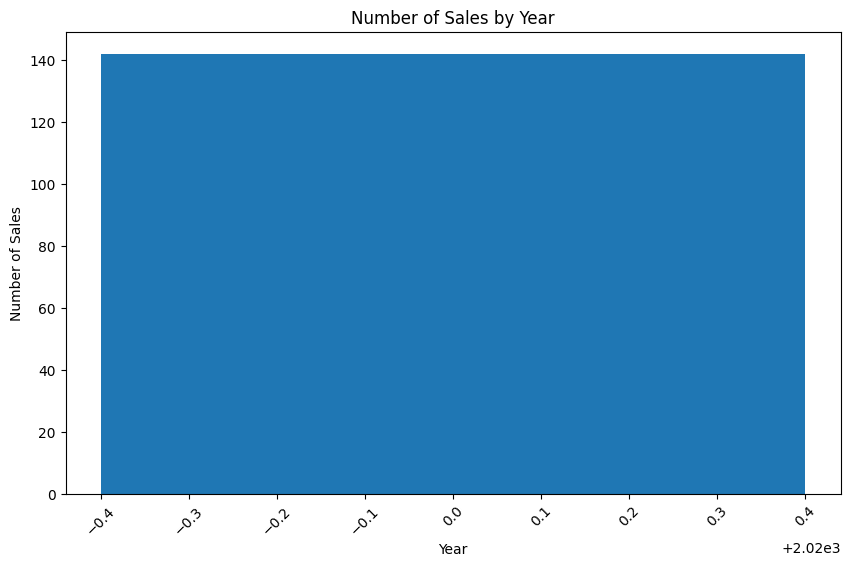

In [17]:
sales_by_year = df_clean['List Year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(sales_by_year.index, sales_by_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.title('Number of Sales by Year')
plt.xticks(rotation=45)
plt.show()